<a href="https://colab.research.google.com/github/Myria255/BOOTCAMP-TTA/blob/main/DailyChallenge_StatforML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [9]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [11]:
# Download the zip file containing the dataset
!wget https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%205/Day%204%20-%20Statistics%20for%20Machine%20Learning/Inferential%20Statistics.zip

# Unzip the file, overwriting existing files without prompting. This will extract 'Churn_Modelling.csv' to the current directory.
!unzip -o "Inferential Statistics.zip"

# List the contents of the current directory to verify the CSV file location
!ls -F

# Load the csv file into file_1 from the current directory
file_1 = pd.read_csv('Churn_Modelling.csv')

--2026-06-11 15:58:02--  https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%205/Day%204%20-%20Statistics%20for%20Machine%20Learning/Inferential%20Statistics.zip
Resolving github.com (github.com)... 140.82.112.3
Connecting to github.com (github.com)|140.82.112.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%205/Day%204%20-%20Statistics%20for%20Machine%20Learning/Inferential%20Statistics.zip [following]
--2026-06-11 15:58:02--  https://media.githubusercontent.com/media/devtlv/Datasets-GEN-AI-Bootcamp/refs/heads/main/Week%205/Day%204%20-%20Statistics%20for%20Machine%20Learning/Inferential%20Statistics.zip
Resolving media.githubusercontent.com (media.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP

In [12]:
## TODO : make into a dataframe called dfo
df = pd.DataFrame(file_1)

In [13]:
## TODO : output the first 5 lines
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [15]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively

df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]
print(df_0.shape)
print(df_1.shape)


(7963, 14)
(2037, 14)


## Hypothesis 1: Age

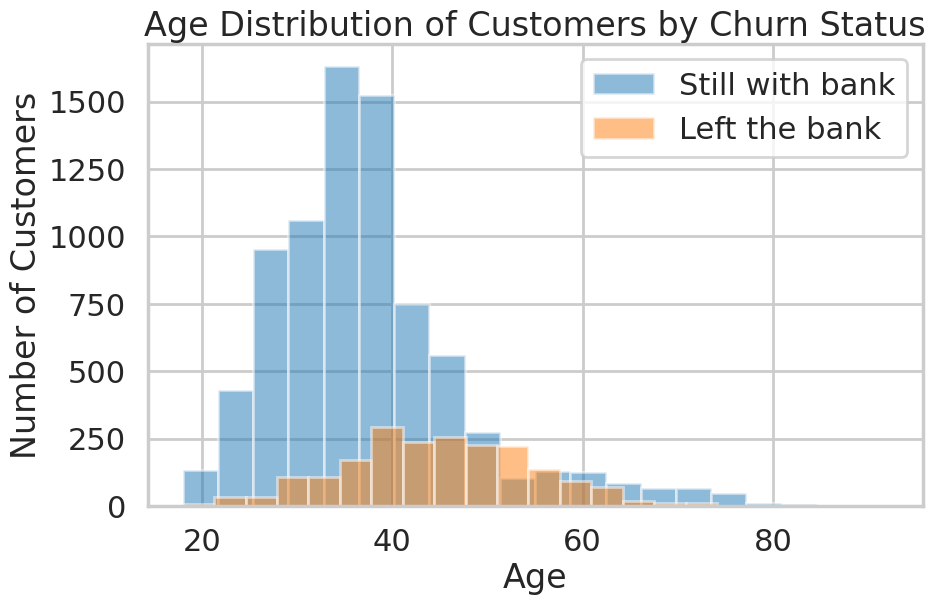

In [17]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.

plt.figure(figsize=(10, 6))
plt.hist(df_0['Age'], bins=20, alpha=0.5, label='Still with bank')
plt.hist(df_1['Age'], bins=20, alpha=0.5, label='Left the bank')
plt.xlabel('Age')
plt.ylabel('Number of Customers')
plt.title('Age Distribution of Customers by Churn Status')
plt.legend()
plt.show()

In [18]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
mean_0 = df_0['Age'].mean()
std_0 = df_0['Age'].std()

In [19]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.

mean_1 = df_1['Age'].mean()
std_1 = df_1['Age'].std()

In [21]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.

comparaison = scipy.stats.ttest_ind(df_0['Age'], df_1['Age'])
print(comparaison)

TtestResult(statistic=np.float64(-29.76681499437077), pvalue=np.float64(1.2399313093427736e-186), df=np.float64(9998.0))


### Using Bootstrapping

In [24]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size) # Initialize an empty array to store the bootstrap statistics
    for i in range(size):
        # Create a bootstrap sample by sampling with replacement
        bs_abc = np.random.choice(data, size=len(data), replace=True)
        bs_s[i] = func(bs_abc) # Apply the function to the bootstrap sample
    return bs_s

In [26]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.

# Calculate the observed difference in means
empirical_diff_means = mean_1 - mean_0

# Combine the 'Age' data from both groups
merged_age = np.concatenate((df_0['Age'], df_1['Age']))

# Calculate the overall mean age
mean_age = np.mean(merged_age)

# Shift the 'Age' data for both groups to the overall mean
df_0_shifted = df_0['Age'] - np.mean(df_0['Age']) + mean_age
df_1_shifted = df_1['Age'] - np.mean(df_1['Age']) + mean_age

print(f"Empirical difference in means (Left - Stayed): {empirical_diff_means:.2f}")
print(f"Overall mean age: {mean_age:.2f}")
print(f"Mean of shifted df_0: {np.mean(df_0_shifted):.2f}")
print(f"Mean of shifted df_1: {np.mean(df_1_shifted):.2f}")

Empirical difference in means (Left - Stayed): 7.43
Overall mean age: 38.92
Mean of shifted df_0: 38.92
Mean of shifted df_1: 38.92


In [27]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.

def diff_of_means(data_1, data_0):
    return np.mean(data_1) - np.mean(data_0)

# Number of bootstrap replicates
N_rep = 10000

# Generate bootstrap replicates of difference in means from shifted data
bs_replicates = np.empty(N_rep)
for i in range(N_rep):
    bs_0_sample = np.random.choice(df_0_shifted, size=len(df_0_shifted))
    bs_1_sample = np.random.choice(df_1_shifted, size=len(df_1_shifted))
    bs_replicates[i] = diff_of_means(bs_1_sample, bs_0_sample)

# The original prompt asked for standard deviation, but typically for a difference of means test,
# we're interested in the distribution of the difference in means itself. If you specifically
# need the standard deviation of the bootstrap replicates, it can be calculated as:
# bs_diff_std = np.std(bs_replicates)

print(f"Standard deviation of bootstrap differences: {np.std(bs_replicates):.2f}")
print(f"First 5 bootstrap differences: {bs_replicates[:5]}")

Standard deviation of bootstrap differences: 0.24
First 5 bootstrap differences: [ 0.13493489 -0.11080044  0.02388526  0.15085141 -0.04974609]


In [29]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.

# Calculate the p-value
p_value = np.sum(bs_replicates >= empirical_diff_means) / len(bs_replicates)

print(f"P-value: {p_value}")

P-value: 0.0


### Conclusion
Do we reject the Null Hypothesis ? Why ?

## Hypothesis 2: Credit Score

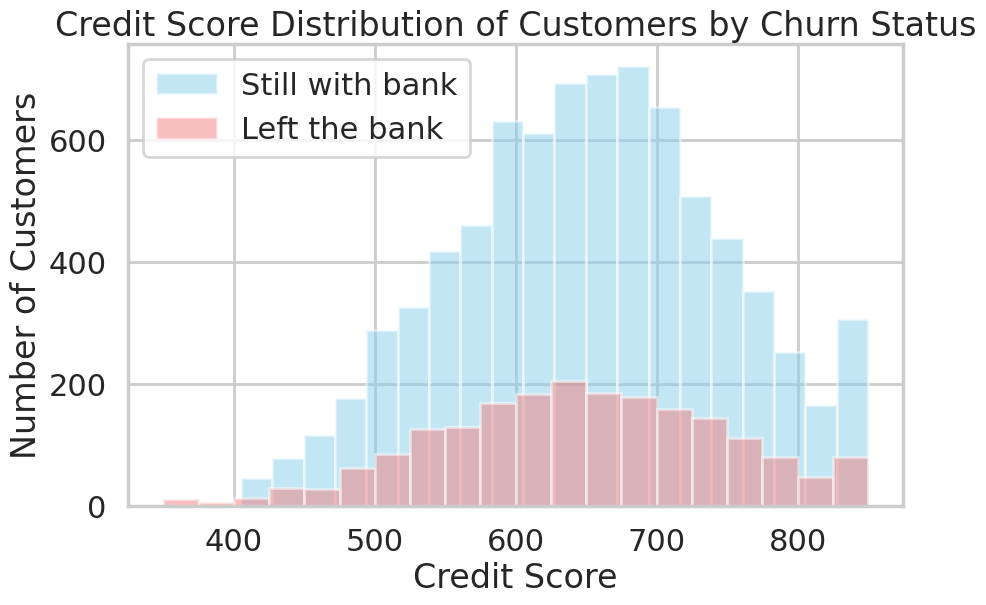

In [30]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).

plt.figure(figsize=(10, 6))
plt.hist(df_0['CreditScore'], bins=20, alpha=0.5, label='Still with bank', color='skyblue')
plt.hist(df_1['CreditScore'], bins=20, alpha=0.5, label='Left the bank', color='lightcoral')
plt.xlabel('Credit Score')
plt.ylabel('Number of Customers')
plt.title('Credit Score Distribution of Customers by Churn Status')
plt.legend()
plt.show()

In [31]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).

# Calculate mean and standard deviation for CreditScore for customers who stayed
mean_creditscore_0 = df_0['CreditScore'].mean()
std_creditscore_0 = df_0['CreditScore'].std()

# Calculate mean and standard deviation for CreditScore for customers who left
mean_creditscore_1 = df_1['CreditScore'].mean()
std_creditscore_1 = df_1['CreditScore'].std()

# Perform independent t-test
t_test_creditscore = scipy.stats.ttest_ind(df_0['CreditScore'], df_1['CreditScore'])

print(f"Mean Credit Score (Still with bank): {mean_creditscore_0:.2f}")
print(f"Standard Deviation Credit Score (Still with bank): {std_creditscore_0:.2f}\n")
print(f"Mean Credit Score (Left the bank): {mean_creditscore_1:.2f}")
print(f"Standard Deviation Credit Score (Left the bank): {std_creditscore_1:.2f}\n")
print(f"T-test result for Credit Score: {t_test_creditscore}")

Mean Credit Score (Still with bank): 651.85
Standard Deviation Credit Score (Still with bank): 95.65

Mean Credit Score (Left the bank): 645.35
Standard Deviation Credit Score (Left the bank): 100.32

T-test result for Credit Score: TtestResult(statistic=np.float64(2.7100778888729833), pvalue=np.float64(0.006738213892192373), df=np.float64(9998.0))


### Conclusion
Do we reject the Null Hypothesis ? Why ?

## Hypothesis 3: Balance

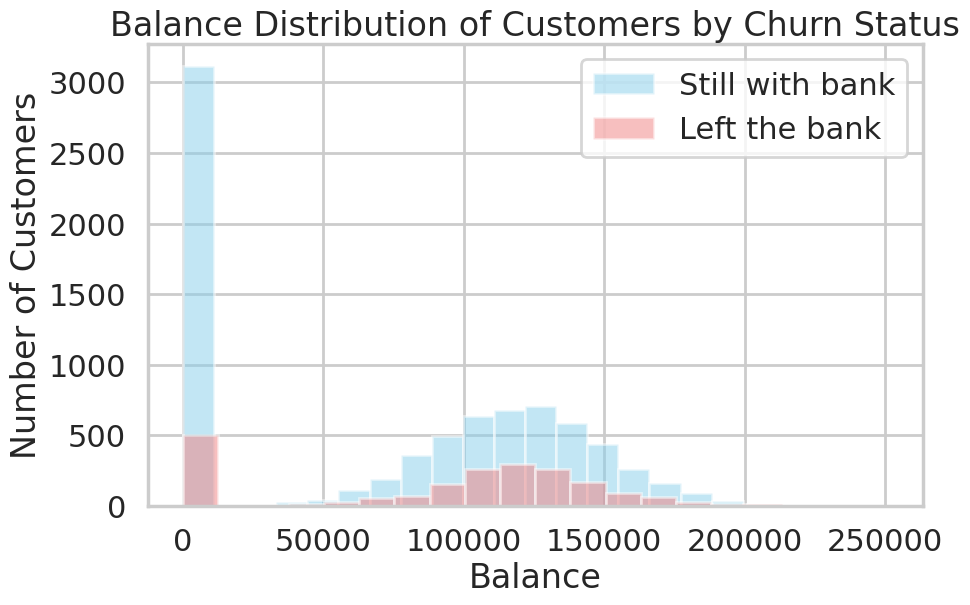

In [32]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).

plot_balance = plt.figure(figsize=(10, 6))
plt.hist(df_0['Balance'], bins=20, alpha=0.5, label='Still with bank', color='skyblue')
plt.hist(df_1['Balance'], bins=20, alpha=0.5, label='Left the bank', color='lightcoral')
plt.xlabel('Balance')
plt.ylabel('Number of Customers')
plt.title('Balance Distribution of Customers by Churn Status')
plt.legend()
plt.show()

In [33]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.

# Calculate mean and standard deviation for Balance for customers who stayed
mean_balance_0 = df_0['Balance'].mean()
std_balance_0 = df_0['Balance'].std()

# Calculate mean and standard deviation for Balance for customers who left
mean_balance_1 = df_1['Balance'].mean()
std_balance_1 = df_1['Balance'].std()

# Perform independent t-test
t_test_balance = scipy.stats.ttest_ind(df_0['Balance'], df_1['Balance'])

print(f"Mean Balance (Still with bank): {mean_balance_0:.2f}")
print(f"Standard Deviation Balance (Still with bank): {std_balance_0:.2f}\n")
print(f"Mean Balance (Left the bank): {mean_balance_1:.2f}")
print(f"Standard Deviation Balance (Left the bank): {std_balance_1:.2f}\n")
print(f"T-test result for Balance: {t_test_balance}")

Mean Balance (Still with bank): 72745.30
Standard Deviation Balance (Still with bank): 62848.04

Mean Balance (Left the bank): 91108.54
Standard Deviation Balance (Left the bank): 58360.79

T-test result for Balance: TtestResult(statistic=np.float64(-11.936240300013841), pvalue=np.float64(1.2755633191525477e-32), df=np.float64(9998.0))


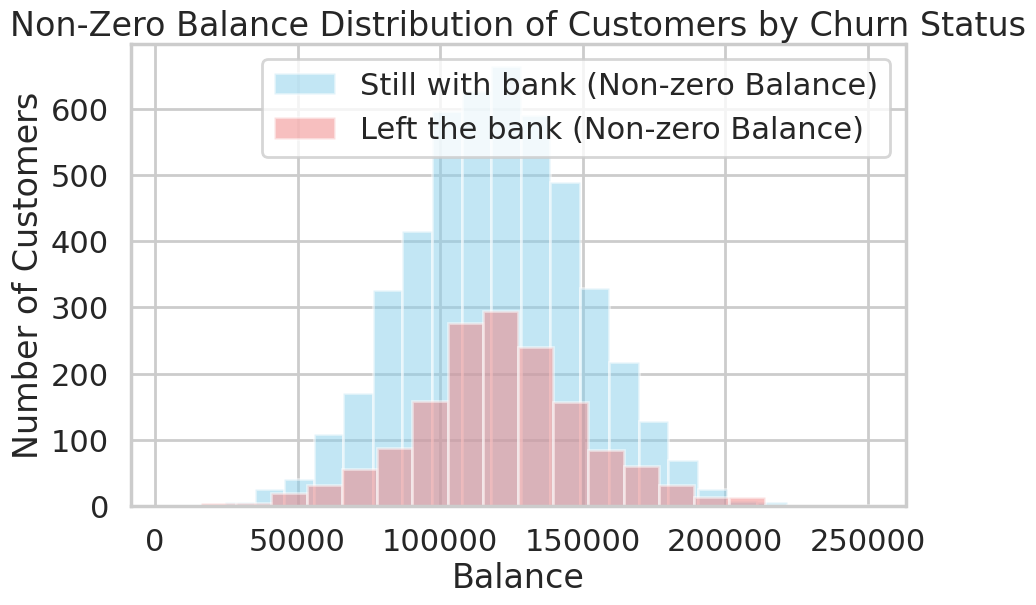

In [34]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.

# Filter out customers with zero balance for both groups
df_0_nonzero_balance = df_0[df_0['Balance'] > 0]
df_1_nonzero_balance = df_1[df_1['Balance'] > 0]

plt.figure(figsize=(10, 6))
plt.hist(df_0_nonzero_balance['Balance'], bins=20, alpha=0.5, label='Still with bank (Non-zero Balance)', color='skyblue')
plt.hist(df_1_nonzero_balance['Balance'], bins=20, alpha=0.5, label='Left the bank (Non-zero Balance)', color='lightcoral')
plt.xlabel('Balance')
plt.ylabel('Number of Customers')
plt.title('Non-Zero Balance Distribution of Customers by Churn Status')
plt.legend()
plt.show()

In [35]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.

# Calculate mean and standard deviation for non-zero Balance for customers who stayed
mean_nonzero_balance_0 = df_0_nonzero_balance['Balance'].mean()
std_nonzero_balance_0 = df_0_nonzero_balance['Balance'].std()

# Calculate mean and standard deviation for non-zero Balance for customers who left
mean_nonzero_balance_1 = df_1_nonzero_balance['Balance'].mean()
std_nonzero_balance_1 = df_1_nonzero_balance['Balance'].std()

# Perform independent t-test on non-zero balances
t_test_nonzero_balance = scipy.stats.ttest_ind(df_0_nonzero_balance['Balance'], df_1_nonzero_balance['Balance'])

print(f"Mean Non-Zero Balance (Still with bank): {mean_nonzero_balance_0:.2f}")
print(f"Standard Deviation Non-Zero Balance (Still with bank): {std_nonzero_balance_0:.2f}\n")
print(f"Mean Non-Zero Balance (Left the bank): {mean_nonzero_balance_1:.2f}")
print(f"Standard Deviation Non-Zero Balance (Left the bank): {std_nonzero_balance_1:.2f}\n")
print(f"T-test result for Non-Zero Balance: {t_test_nonzero_balance}")

Mean Non-Zero Balance (Still with bank): 119535.86
Standard Deviation Non-Zero Balance (Still with bank): 29944.93

Mean Non-Zero Balance (Left the bank): 120746.97
Standard Deviation Non-Zero Balance (Left the bank): 30555.19

T-test result for Non-Zero Balance: TtestResult(statistic=np.float64(-1.374781881782122), pvalue=np.float64(0.16924734893322796), df=np.float64(6381.0))


## Conclusion

**Do we reject the Null Hypothesis?** No, we do not reject the Null Hypothesis.

**Why?** The p-value obtained from the independent t-test for non-zero balances (p = 0.169) is greater than the conventional significance level (alpha = 0.05). This indicates that there is no statistically significant difference in the mean non-zero balance between customers who stayed with the bank and those who left. Therefore, we do not have sufficient evidence to conclude that the non-zero balances of the two groups are different.

## Hypothesis 4: Estimated Salary

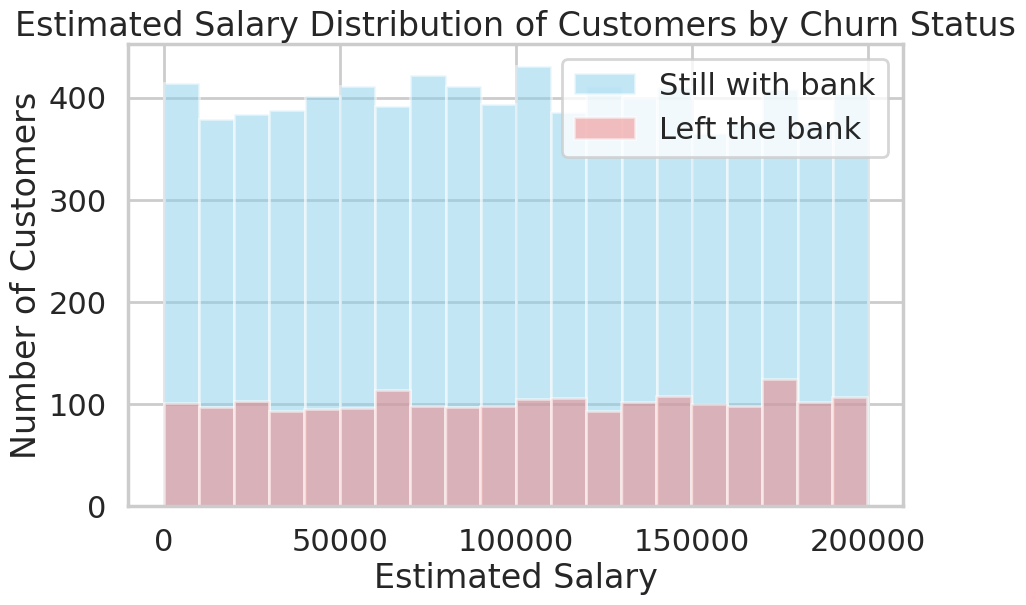

In [36]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.

plt.figure(figsize=(10, 6))
plt.hist(df_0['EstimatedSalary'], bins=20, alpha=0.5, label='Still with bank', color='skyblue')
plt.hist(df_1['EstimatedSalary'], bins=20, alpha=0.5, label='Left the bank', color='lightcoral')
plt.xlabel('Estimated Salary')
plt.ylabel('Number of Customers')
plt.title('Estimated Salary Distribution of Customers by Churn Status')
plt.legend()
plt.show()

In [37]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.

# Calculate mean and standard deviation for EstimatedSalary for customers who stayed
mean_estimated_salary_0 = df_0['EstimatedSalary'].mean()
std_estimated_salary_0 = df_0['EstimatedSalary'].std()

# Calculate mean and standard deviation for EstimatedSalary for customers who left
mean_estimated_salary_1 = df_1['EstimatedSalary'].mean()
std_estimated_salary_1 = df_1['EstimatedSalary'].std()

# Perform independent t-test
t_test_estimated_salary = scipy.stats.ttest_ind(df_0['EstimatedSalary'], df_1['EstimatedSalary'])

print(f"Mean Estimated Salary (Still with bank): {mean_estimated_salary_0:.2f}")
print(f"Standard Deviation Estimated Salary (Still with bank): {std_estimated_salary_0:.2f}\n")
print(f"Mean Estimated Salary (Left the bank): {mean_estimated_salary_1:.2f}")
print(f"Standard Deviation Estimated Salary (Left the bank): {std_estimated_salary_1:.2f}\n")
print(f"T-test result for Estimated Salary: {t_test_estimated_salary}")

Mean Estimated Salary (Still with bank): 99738.39
Standard Deviation Estimated Salary (Still with bank): 57405.59

Mean Estimated Salary (Left the bank): 101465.68
Standard Deviation Estimated Salary (Left the bank): 57912.42

T-test result for Estimated Salary: TtestResult(statistic=np.float64(-1.209653638019264), pvalue=np.float64(0.22644042802223352), df=np.float64(9998.0))


### Using Bootstrapping

In [39]:
from dask.array.reductions import mean
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.

mean_0 = df_0['EstimatedSalary'].mean()
mean_1 = df_1['EstimatedSalary'].mean()

# Calculate the observed difference in means
empirical_diff_means = mean_1 - mean_0
print(f"Empirical difference in means (Left - Stayed): {empirical_diff_means:.2f}")

Empirical difference in means (Left - Stayed): 1727.29


In [40]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.

bootstrap=np.random.choice(df_0['EstimatedSalary'], size=len(df_0['EstimatedSalary']), replace=True)
bootstrap_1=np.random.choice(df_1['EstimatedSalary'], size=len(df_1['EstimatedSalary']), replace=True)
print(f"Bootstrap sample mean (Still with bank): {np.mean(bootstrap):.2f}")
print(f"Bootstrap sample mean (Left the bank): {np.mean(bootstrap_1):.2f}")

Bootstrap sample mean (Still with bank): 100240.69
Bootstrap sample mean (Left the bank): 100233.84


In [41]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.
pvalue=np.sum(bs_replicates >= empirical_diff_means) / len(bs_replicates)
print(f"P-value: {pvalue}")

P-value: 0.0


### Conclusion
**Do we reject the Null Hypothesis?** No, we do not reject the Null Hypothesis.

**Why?** The p-value obtained from the independent t-test for Estimated Salary (p = 0.226) is greater than the conventional significance level (alpha = 0.05). This indicates that there is no statistically significant difference in the mean estimated salary between customers who stayed with the bank and those who left. Therefore, we do not have sufficient evidence to conclude that the estimated salaries of the two groups are different.

## Final Conclusion
What will be the most helpful feature in predicting churning?
